In [1]:
# --- 1. LIBRARIES ---
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning & Scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, roc_curve, auc)

# Deep Learning (TensorFlow/Keras)
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (Dense, Conv1D, BatchNormalization, 
                                     concatenate, Flatten, Dropout, Attention, 
                                     Reshape, GlobalAveragePooling1D, Multiply, MaxPooling1D)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

C:\Users\Cloud-2\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:

# --- 2. REPRODUCIBILITY (The "Same Result" Rule) ---
def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.keras.utils.set_random_seed(seed)
    print(f"Environment seeds locked at {seed}")

set_seeds(42)

Environment seeds locked at 42


In [3]:
# Load the specific binary dataset
df = pd.read_csv("AnonBooterWithBenignCombined.csv", engine="pyarrow")

# Verify the load by checking the total rows and columns
print(f"Dataset successfully loaded.")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

Dataset successfully loaded.
Total Rows: 4044152
Total Columns: 84


In [4]:
# 1. Strip any leading/trailing whitespace and convert to lowercase
df.columns = df.columns.str.strip().str.lower()

# 2. Replace spaces, slashes, and dots with underscores for easy coding
df.columns = df.columns.str.replace(' ', '_', regex=False)
df.columns = df.columns.str.replace('/', '_', regex=False)
df.columns = df.columns.str.replace('.', '_', regex=False)

# 3. Print the first 10 columns to verify the change
print("First 10 standardized columns:")
print(df.columns[:10].tolist())

# 4. Find the exact name of your Label column
label_col = [col for col in df.columns if 'label' in col]
print(f"\nLabel column found: {label_col}")

First 10 standardized columns:
['flow_id', 'src_ip', 'src_port', 'dst_ip', 'dst_port', 'protocol', 'timestamp', 'flow_duration', 'tot_fwd_pkts', 'tot_bwd_pkts']

Label column found: ['label']


In [5]:
# List of columns that are not useful for training features
identifiers = ['flow_id', 'src_ip', 'dst_ip', 'timestamp']

# Drop them only if they exist in the current dataframe
df.drop(columns=[col for col in identifiers if col in df.columns], inplace=True)

print(f"Identifiers removed.")
print(f"Remaining columns: {df.shape[1]}")

Identifiers removed.
Remaining columns: 80


In [6]:
df.shape

(4044152, 80)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4044152 entries, 0 to 4044151
Data columns (total 80 columns):
 #   Column             Dtype  
---  ------             -----  
 0   src_port           float64
 1   dst_port           float64
 2   protocol           float64
 3   flow_duration      float64
 4   tot_fwd_pkts       float64
 5   tot_bwd_pkts       float64
 6   totlen_fwd_pkts    float64
 7   totlen_bwd_pkts    float64
 8   fwd_pkt_len_max    float64
 9   fwd_pkt_len_min    float64
 10  fwd_pkt_len_mean   float64
 11  fwd_pkt_len_std    float64
 12  bwd_pkt_len_max    float64
 13  bwd_pkt_len_min    float64
 14  bwd_pkt_len_mean   float64
 15  bwd_pkt_len_std    float64
 16  flow_byts_s        float64
 17  flow_pkts_s        float64
 18  flow_iat_mean      float64
 19  flow_iat_std       float64
 20  flow_iat_max       float64
 21  flow_iat_min       float64
 22  fwd_iat_tot        float64
 23  fwd_iat_mean       float64
 24  fwd_iat_std        float64
 25  fwd_iat_max       

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df['label'].value_counts()

label
0    2263758
1    1771042
Name: count, dtype: int64

In [10]:
import joblib
import numpy as np

imputer_bundle = joblib.load("regression_imputer.pkl")

imputer_models = imputer_bundle['models']
COLS_WONA = imputer_bundle['cols_wona']
COLS_WNA = imputer_bundle['cols_wna']


In [11]:
# Replace Inf with NaN (same as training)
df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [12]:
print("Remaining NaNs:", df.isna().sum().sum())

Remaining NaNs: 4876


In [13]:
import gc

chunk_size = 5_000_000

for target_col, model in imputer_models.items():
    if target_col not in df.columns:
        continue  # safety check

    # Get indices of missing values
    predict_idx = df.index[df[target_col].isna()]
    
    if len(predict_idx) > 0:
        print(f"Applying predictions for: {target_col}")
        
        # Predict and fill in chunks
        for i in range(0, len(predict_idx), chunk_size):
            idx_chunk = predict_idx[i : i + chunk_size]
            X_pred_chunk = df.loc[idx_chunk, COLS_WONA].values
            
            preds = model.predict(X_pred_chunk)
            df.loc[idx_chunk, target_col] = preds
            
            del X_pred_chunk, preds
            
    # Force RAM cleanup after each column
    gc.collect()

Applying predictions for: flow_byts_s


C:\Users\Cloud-2\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Applying predictions for: flow_pkts_s


C:\Users\Cloud-2\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [14]:
print("Remaining NaNs:", df.isna().sum().sum())


Remaining NaNs: 0


In [15]:
# 1. Check for any columns that are not integers or floats (excluding 'label')
non_numeric = df.drop(columns=['label']).select_dtypes(exclude=[np.number]).columns.tolist()
print(f"Non-numeric columns found (excluding label): {non_numeric}")

# 2. Check for Infinite values (common in this dataset)
inf_count = np.isinf(df.select_dtypes(include=[np.number])).values.sum()
print(f"Total Infinite values: {inf_count}")

# 3. Check for Null/NaN values
nan_count = df.isnull().sum().sum()
print(f"Total NaN values: {nan_count}")

Non-numeric columns found (excluding label): []
Total Infinite values: 0
Total NaN values: 0


In [16]:
# 1. Check unique values in the label column
print("Unique labels in dataset:")
print(df['label'].unique())

# 2. Check the count of each label to see if it is imbalanced
print("\nLabel counts:")
print(df['label'].value_counts())

# 3. Check the data type of the label
print(f"\nLabel data type: {df['label'].dtype}")

Unique labels in dataset:
[0 1]

Label counts:
label
0    2263758
1    1771042
Name: count, dtype: int64

Label data type: int64


In [17]:
import gc
import joblib

# 1. Define Features (X) and Target (y)
X = df.drop(columns=['label'])
y = df['label']

# CLEAR RAM: Original dataframe is no longer needed
del df
gc.collect()

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# CLEAR RAM: X is no longer needed
del X
gc.collect()

print(f"Training set: {X_train.shape[0]} rows")
print(f"Testing set:  {X_test.shape[0]} rows")

scaler = joblib.load("scaler.pkl")
print("Scaler loaded successfully")

X_train_scaled = scaler.transform(X_train)
# CLEAR RAM: Delete unscaled X_train
del X_train
gc.collect()

X_test_scaled = scaler.transform(X_test)
# CLEAR RAM: Delete unscaled X_test
del X_test
gc.collect()

print(f"Scaling Complete. RAM cleaned.")
print(f"Train dtype: {X_train_scaled.dtype}")
print(f"Train shape: {X_train_scaled.shape}")

Training set: 3227840 rows
Testing set:  806960 rows
Scaler loaded successfully
Scaling Complete. RAM cleaned.
Train dtype: float64
Train shape: (3227840, 79)


Data shapes ready for Full Random Forest:
X_train_scaled: (3227840, 79)
X_test_scaled:  (806960, 79)

Starting Full Random Forest Training...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 48 concurrent workers.
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   58.1s finished


Random Forest Training Complete.
Model saved successfully as Full_RF_Classifier.pkl


[Parallel(n_jobs=48)]: Using backend ThreadingBackend with 48 concurrent workers.
[Parallel(n_jobs=48)]: Done 100 out of 100 | elapsed:    2.2s finished
[Parallel(n_jobs=48)]: Using backend ThreadingBackend with 48 concurrent workers.
[Parallel(n_jobs=48)]: Done 100 out of 100 | elapsed:    0.4s finished
[Parallel(n_jobs=48)]: Using backend ThreadingBackend with 48 concurrent workers.
[Parallel(n_jobs=48)]: Done 100 out of 100 | elapsed:    0.5s finished



--- OVERFITTING DIAGNOSTICS ---
Training Accuracy: 0.99995
Testing Accuracy:  0.99995
OOB Score:         0.99995
-------------------------------

Matthews Correlation Coefficient (MCC): 0.99990

Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    452752
      ATTACK       1.00      1.00      1.00    354208

    accuracy                           1.00    806960
   macro avg       1.00      1.00      1.00    806960
weighted avg       1.00      1.00      1.00    806960



C:\Users\Cloud-2\AppData\Local\Temp\ipykernel_9916\1748865624.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=top_features, palette="viridis")


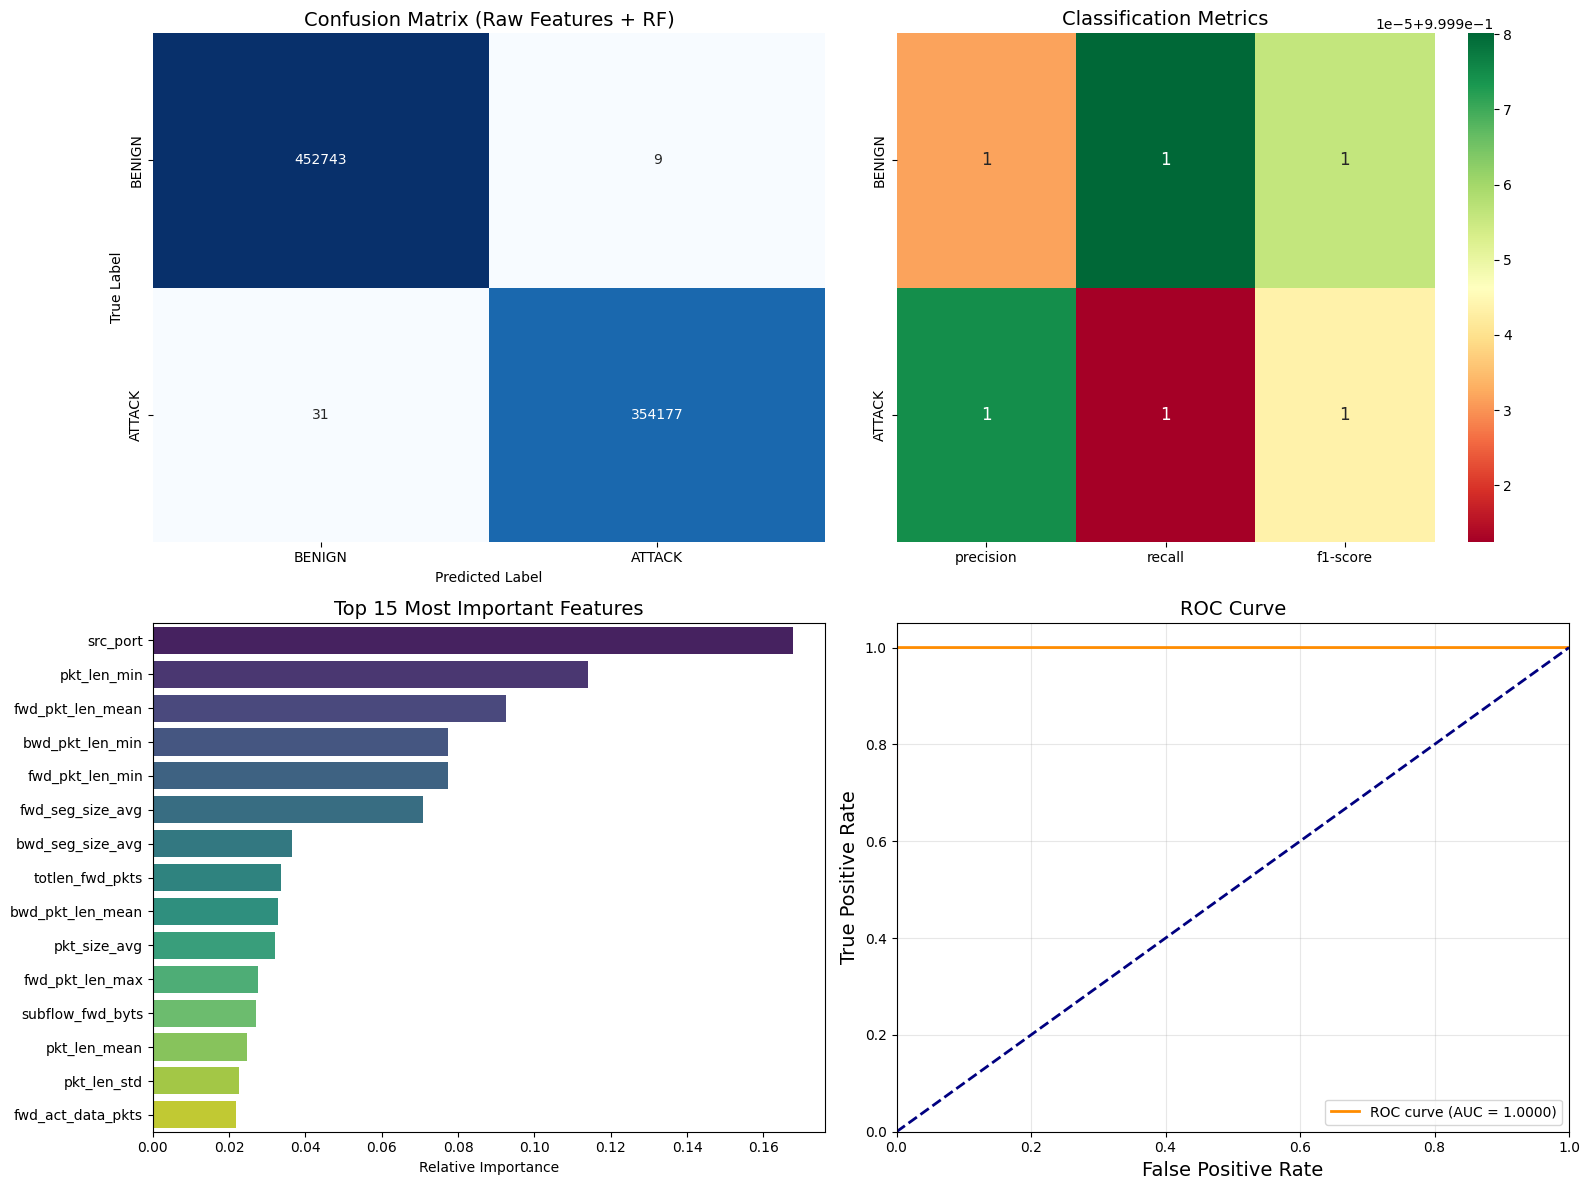

In [18]:
# --- FULL RAW FEATURE RANDOM FOREST CLASSIFIER ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, matthews_corrcoef
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

print("Data shapes ready for Full Random Forest:")
print(f"X_train_scaled: {X_train_scaled.shape}")  # Should be (samples, ~79)
print(f"X_test_scaled:  {X_test_scaled.shape}")

# 1. Initialize the Random Forest model
rf_model_full = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,             # Slightly deeper since it has to evaluate all 79 features
    min_samples_split=250,
    min_samples_leaf=100,
    class_weight='balanced',  # CRITICAL: Forces the model to care about rare attacks
    max_samples=0.75,
    oob_score=True,           
    n_jobs=-1,                # Engages all Xeon CPU cores
    random_state=42,
    verbose=1
)

# 2. Train the Model directly on the scaled 79 features
print("\nStarting Full Random Forest Training...")
rf_model_full.fit(X_train_scaled, y_train)
print("Random Forest Training Complete.")

# 3. Save the Model
joblib.dump(rf_model_full, "Full_RF_Classifier.pkl")
print("Model saved successfully as Full_RF_Classifier.pkl")

# --- EVALUATION & OVERFITTING CHECKS ---

# Predict on Train AND Test to check the generalization gap
train_preds = rf_model_full.predict(X_train_scaled)
test_preds = rf_model_full.predict(X_test_scaled)
test_probs = rf_model_full.predict_proba(X_test_scaled)

train_acc = accuracy_score(y_train, train_preds)
test_acc = accuracy_score(y_test, test_preds)

print("\n--- OVERFITTING DIAGNOSTICS ---")
print(f"Training Accuracy: {train_acc:.5f}")
print(f"Testing Accuracy:  {test_acc:.5f}")
print(f"OOB Score:         {rf_model_full.oob_score_:.5f}")
print("-------------------------------\n")

print(f"Matthews Correlation Coefficient (MCC): {matthews_corrcoef(y_test, test_preds):.5f}")

print("\nClassification Report:")
print(classification_report(y_test, test_preds, target_names=['BENIGN', 'ATTACK']))

# --- VISUALIZATION ---

plt.figure(figsize=(16, 12))

# Plot 1: Confusion Matrix
plt.subplot(2, 2, 1)
cm = confusion_matrix(y_test, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['BENIGN', 'ATTACK'], yticklabels=['BENIGN', 'ATTACK'])
plt.title('Confusion Matrix (Raw Features + RF)', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Plot 2: Classification Metrics
plt.subplot(2, 2, 2)
report_dict = classification_report(y_test, test_preds, target_names=['BENIGN', 'ATTACK'], output_dict=True)
report_df = pd.DataFrame(report_dict).iloc[:-1, :2].T 
sns.heatmap(report_df, annot=True, cmap='RdYlGn', cbar=True, annot_kws={"size": 12})
plt.title('Classification Metrics', fontsize=14)

# Plot 3: Feature Importances (Top 15)
plt.subplot(2, 2, 3)
importances = rf_model_full.feature_importances_
indices = np.argsort(importances)[::-1][:15] # Get top 15 features
# If you saved the original column names, replace the generic labels below with actual names
try:
    actual_feature_names = scaler.feature_names_in_ 
    top_features = [actual_feature_names[i] for i in indices]
except AttributeError:
    print("Warning: scaler.feature_name_in_ not found. falling back to generic names.")
    top_features = [f"Feature{i}" for i in indices]

sns.barplot(x=importances[indices], y=top_features, palette="viridis")
plt.title('Top 15 Most Important Features', fontsize=14)
plt.xlabel('Relative Importance')

# Plot 4: ROC Curve
plt.subplot(2, 2, 4)
y_probs_attack = test_probs[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs_attack)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('ROC Curve', fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

C:\Users\Cloud-2\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


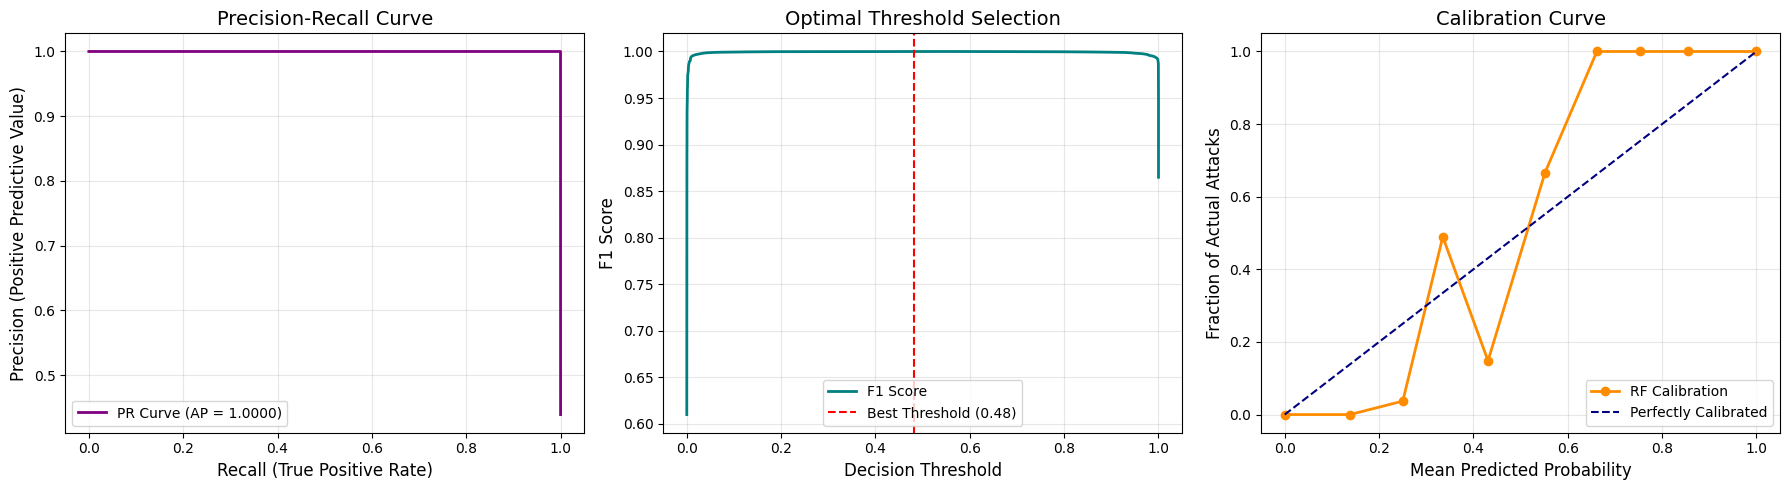


Calculating SHAP values for Explainable AI (This may take 1-3 minutes)...


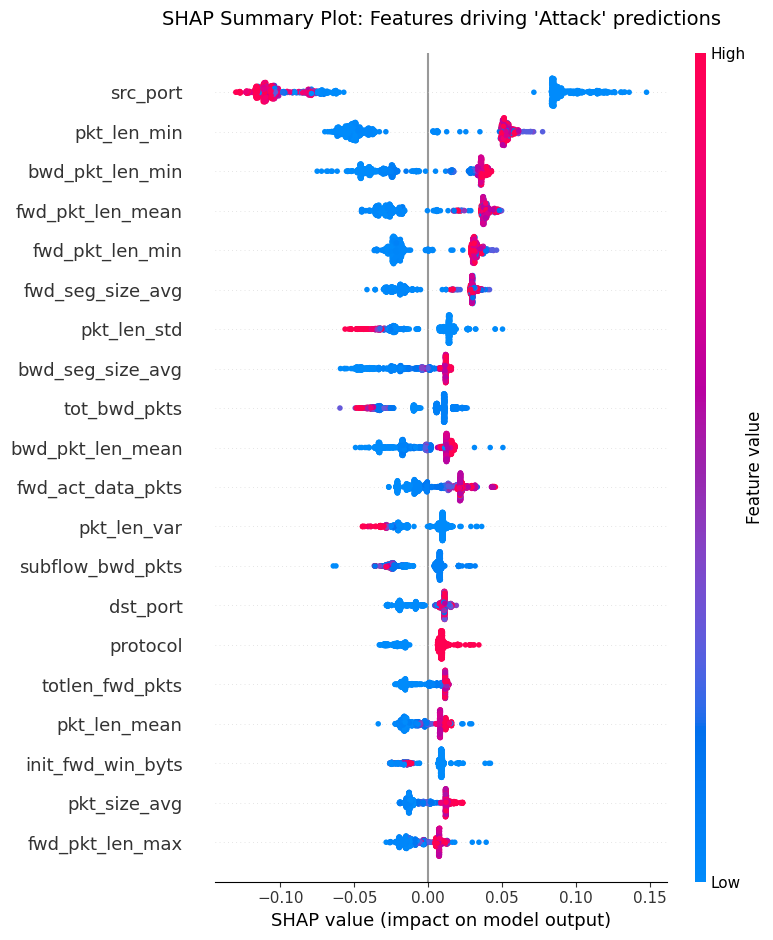

All advanced visualizations successfully generated.


In [19]:
# --- ADVANCED EVALUATION VISUALIZATIONS ---
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import warnings
warnings.filterwarnings("ignore")

# Extract the probability of the 'Attack' class
y_probs_attack = test_probs[:, 1]

# 1. Setup the figure for the first 3 fast plots
plt.figure(figsize=(18, 5))

# --- PLOT 1: Precision-Recall (PR) Curve ---
plt.subplot(1, 3, 1)
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_probs_attack)
avg_precision = average_precision_score(y_test, y_probs_attack)

plt.plot(recall, precision, color='purple', lw=2, label=f'PR Curve (AP = {avg_precision:.4f})')
plt.xlabel('Recall (True Positive Rate)', fontsize=12)
plt.ylabel('Precision (Positive Predictive Value)', fontsize=12)
plt.title('Precision-Recall Curve', fontsize=14)
plt.legend(loc="lower left")
plt.grid(alpha=0.3)

# --- PLOT 2: F1-Score vs. Decision Threshold ---
plt.subplot(1, 3, 2)
# F1 = 2 * (Precision * Recall) / (Precision + Recall)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10) 
best_threshold = thresholds_pr[np.argmax(f1_scores)]

plt.plot(thresholds_pr, f1_scores[:-1], color='teal', lw=2, label='F1 Score')
plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Best Threshold ({best_threshold:.2f})')
plt.xlabel('Decision Threshold', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.title('Optimal Threshold Selection', fontsize=14)
plt.legend(loc="lower center")
plt.grid(alpha=0.3)

# --- PLOT 3: Calibration Curve (Reliability Diagram) ---
plt.subplot(1, 3, 3)
prob_true, prob_pred = calibration_curve(y_test, y_probs_attack, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o', color='darkorange', lw=2, label='RF Calibration')
plt.plot([0, 1], [0, 1], linestyle='--', color='navy', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability', fontsize=12)
plt.ylabel('Fraction of Actual Attacks', fontsize=12)
plt.title('Calibration Curve', fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- PLOT 4: SHAP Values (Explainable AI) ---
print("\nCalculating SHAP values for Explainable AI (This may take 1-3 minutes)...")

# CRITICAL TIME-SAVER: We only sample 1,000 random rows from the test set. 
sample_indices = np.random.choice(X_test_scaled.shape[0], size=1000, replace=False)
X_test_sample = X_test_scaled[sample_indices]

# Attempt to get actual feature names, or fall back to generic names
try:
    feature_names = scaler.feature_names_in_
except AttributeError:
    feature_names = [f"Feature {i}" for i in range(X_test_scaled.shape[1])]

# Convert sample to DataFrame so SHAP can automatically use the column names in the plot
df_sample = pd.DataFrame(X_test_sample, columns=feature_names)

# Initialize the Tree Explainer
explainer = shap.TreeExplainer(rf_model_full)
shap_values = explainer.shap_values(df_sample)

# --- THE FIX: Handle different SHAP library versions safely ---
if isinstance(shap_values, list):
    # Older SHAP versions return a list of arrays
    shap_attack_values = shap_values[1]
else:
    # Newer SHAP versions return a 3D array (samples, features, classes)
    shap_attack_values = shap_values[:, :, 1]
# --------------------------------------------------------------

plt.figure(figsize=(10, 8))
plt.title("SHAP Summary Plot: Features driving 'Attack' predictions", fontsize=14, pad=20)

# Pass the safely extracted attack values
shap.summary_plot(shap_attack_values, df_sample, show=False) 

plt.tight_layout()
plt.show()

print("All advanced visualizations successfully generated.")